<a href="https://colab.research.google.com/github/saswanth01/MLA0304/blob/main/Lab/11_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11

Training: DQN


/tmp/ipykernel_115087/1504963325.py:178: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states).to(device)


Training: DDQN
Training: Dueling
Training: PER


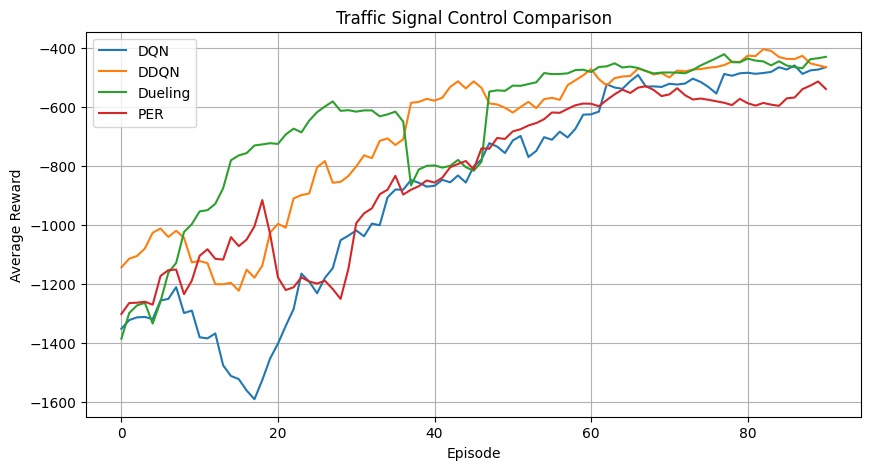

DQN Average Reward: -465.6
DDQN Average Reward: -465.5
Dueling Average Reward: -430.6
PER Average Reward: -539.6


In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Traffic Environment
class TrafficEnv:
    def __init__(self):
        self.max_steps = 50
        self.reset()

    def reset(self):
        self.cars = np.random.randint(0, 10, 4)
        self.signal = 0
        self.step_count = 0
        return self.cars / 10.0

    def step(self, action):
        self.signal = action

        # Cars arrive
        self.cars += np.random.randint(0, 3, 4)

        # Green signal allows cars to move
        self.cars[action] = max(0, self.cars[action] - 5)

        waiting = np.sum(self.cars)
        reward = -waiting

        self.step_count += 1
        done = self.step_count >= self.max_steps

        return self.cars / 10.0, reward, done


# Neural Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )

    def forward(self, x):
        return self.net(x)


# Dueling Network
class DuelingDQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()

        self.feature = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU()
        )

        self.value = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        self.advantage = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, action_size)
        )

    def forward(self, x):
        x = self.feature(x)
        value = self.value(x)
        advantage = self.advantage(x)

        return value + advantage - advantage.mean(dim=1, keepdim=True)


# Prioritized Experience Replay
class PER:
    def __init__(self, capacity=5000):
        self.memory = deque(maxlen=capacity)

    def add(self, experience, priority=1.0):
        self.memory.append((priority, experience))

    def sample(self, batch_size):
        priorities = np.array([x[0] for x in self.memory])
        probs = priorities / priorities.sum()

        indexes = np.random.choice(
            len(self.memory),
            batch_size,
            p=probs
        )

        return [self.memory[i][1] for i in indexes]

    def __len__(self):
        return len(self.memory)


# Training function
def train_agent(method, episodes=100):

    env = TrafficEnv()

    state_size = 4
    action_size = 4

    if method == "Dueling":
        model = DuelingDQN(state_size, action_size).to(device)
        target = DuelingDQN(state_size, action_size).to(device)
    else:
        model = DQN(state_size, action_size).to(device)
        target = DQN(state_size, action_size).to(device)

    target.load_state_dict(model.state_dict())

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    if method == "PER":
        memory = PER()
    else:
        memory = deque(maxlen=5000)

    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.97

    rewards = []

    for episode in range(episodes):

        state = env.reset()
        total_reward = 0

        for t in range(50):

            # Epsilon greedy
            if random.random() < epsilon:
                action = random.randrange(action_size)
            else:
                with torch.no_grad():
                    s = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = model(s).argmax().item()

            next_state, reward, done = env.step(action)

            experience = (state, action, reward, next_state, done)

            if method == "PER":
                memory.add(experience, abs(reward) + 1)
            else:
                memory.append(experience)

            state = next_state
            total_reward += reward

            if len(memory) >= 32:

                if method == "PER":
                    batch = memory.sample(32)
                else:
                    batch = random.sample(memory, 32)

                states, actions, rs, next_states, dones = zip(*batch)

                states = torch.FloatTensor(states).to(device)
                actions = torch.LongTensor(actions).to(device)
                rs = torch.FloatTensor(rs).to(device)
                next_states = torch.FloatTensor(next_states).to(device)
                dones = torch.FloatTensor(dones).to(device)

                q_values = model(states)
                q_values = q_values.gather(
                    1, actions.unsqueeze(1)
                ).squeeze()

                with torch.no_grad():

                    if method == "DDQN":

                        next_actions = model(next_states).argmax(
                            1, keepdim=True
                        )

                        next_q = target(next_states).gather(
                            1, next_actions
                        ).squeeze()

                    else:

                        next_q = target(next_states).max(
                            1
                        )[0]

                    target_q = rs + gamma * next_q * (1 - dones)

                loss = nn.MSELoss()(q_values, target_q)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if done:
                break

        rewards.append(total_reward)

        epsilon = max(
            epsilon_min,
            epsilon * epsilon_decay
        )

        if episode % 10 == 0:
            target.load_state_dict(model.state_dict())

    return rewards


# Train all algorithms
results = {}

for method in ["DQN", "DDQN", "Dueling", "PER"]:

    print("Training:", method)

    results[method] = train_agent(
        method,
        episodes=100
    )


# Plot results
plt.figure(figsize=(10, 5))

for method, rewards in results.items():

    # Moving average
    avg = np.convolve(
        rewards,
        np.ones(10) / 10,
        mode="valid"
    )

    plt.plot(avg, label=method)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Traffic Signal Control Comparison")
plt.legend()
plt.grid()
plt.show()


# Print final performance
for method, rewards in results.items():

    print(
        method,
        "Average Reward:",
        round(np.mean(rewards[-10:]), 2)
    )

12


Episode: 0 Reward: -9.88
Episode: 25 Reward: -104.94
Episode: 50 Reward: -133.38
Episode: 75 Reward: -92.09
Episode: 100 Reward: -5.89
Episode: 125 Reward: 9.05
Episode: 150 Reward: -69.65
Episode: 175 Reward: -106.22
Episode: 200 Reward: -112.57
Episode: 225 Reward: -160.11
Episode: 250 Reward: -151.45
Episode: 275 Reward: -88.11


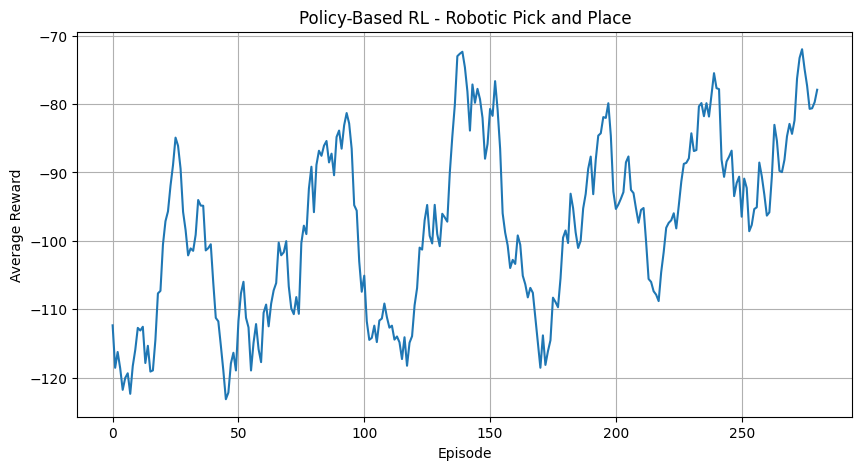

Target Not Reached
Final Reward: -135.8


In [3]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Robotic Arm Environment
class RobotEnv:
    def reset(self):
        self.robot = np.random.uniform(-1, 1, 2)
        self.target = np.random.uniform(-1, 1, 2)
        return np.concatenate([self.robot, self.target])

    def step(self, action):
        moves = np.array([
            [0.1, 0],
            [-0.1, 0],
            [0, 0.1],
            [0, -0.1]
        ])

        self.robot += moves[action]
        self.robot = np.clip(self.robot, -1, 1)

        distance = np.linalg.norm(self.robot - self.target)
        reward = -distance
        done = distance < 0.1

        if done:
            reward += 10

        return np.concatenate([self.robot, self.target]), reward, done


# Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 4),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


# Initialize
env = RobotEnv()
policy = PolicyNetwork().to(device)
optimizer = optim.Adam(policy.parameters(), lr=0.001)

gamma = 0.99
episodes = 300
reward_history = []

# REINFORCE Training
for episode in range(episodes):

    state = env.reset()
    log_probs = []
    rewards = []

    for step in range(100):

        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

        probabilities = policy(state_tensor)

        distribution = torch.distributions.Categorical(probabilities)
        action = distribution.sample()

        next_state, reward, done = env.step(action.item())

        log_probs.append(distribution.log_prob(action))
        rewards.append(reward)

        state = next_state

        if done:
            break

    # Discounted rewards
    returns = []
    G = 0

    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    ).to(device)

    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # Policy gradient
    loss = 0

    for log_prob, G in zip(log_probs, returns):
        loss += -log_prob * G

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_reward = sum(rewards)
    reward_history.append(total_reward)

    if episode % 25 == 0:
        print(
            "Episode:", episode,
            "Reward:", round(total_reward, 2)
        )


# Training Graph
plt.figure(figsize=(10, 5))

average_reward = np.convolve(
    reward_history,
    np.ones(20) / 20,
    mode="valid"
)

plt.plot(average_reward)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Policy-Based RL - Robotic Pick and Place")
plt.grid()
plt.show()


# Test Trained Agent
state = env.reset()
total_reward = 0

for step in range(100):

    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

    with torch.no_grad():
        action = policy(state_tensor).argmax().item()

    state, reward, done = env.step(action)
    total_reward += reward

    if done:
        print("Target Reached!")
        print("Steps:", step + 1)
        break

else:
    print("Target Not Reached")

print("Final Reward:", round(total_reward, 2))

13

Episode: 0 | Reward: -123.56 | Success Rate: 0.0 %
Episode: 50 | Reward: -80.99 | Success Rate: 0.0 %
Episode: 100 | Reward: -103.93 | Success Rate: 2.0 %
Episode: 150 | Reward: -123.64 | Success Rate: 2.0 %
Episode: 200 | Reward: -46.97 | Success Rate: 2.0 %
Episode: 250 | Reward: -84.88 | Success Rate: 2.0 %
Episode: 300 | Reward: -105.43 | Success Rate: 0.0 %
Episode: 350 | Reward: -67.71 | Success Rate: 0.0 %
Episode: 400 | Reward: -109.39 | Success Rate: 2.0 %
Episode: 450 | Reward: -87.12 | Success Rate: 4.0 %


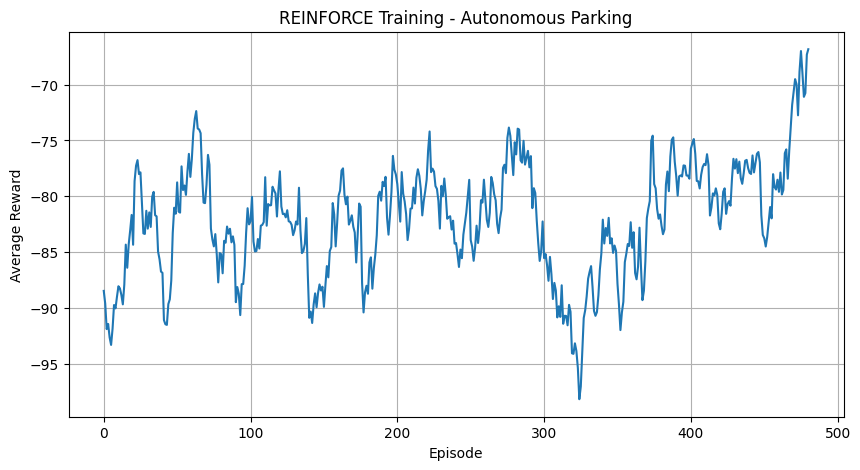

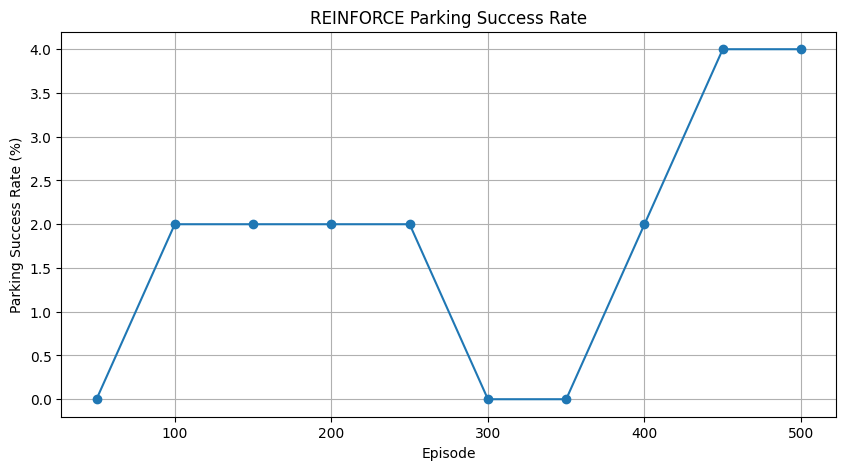


========== FINAL RESULTS ==========
Test Episodes: 100
Successful Parking: 1
Success Rate: 1.0 %
Average Test Reward: -75.64


In [4]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# Autonomous Parking Environment
# ==============================

class ParkingEnv:

    def reset(self):
        # Car position and orientation
        self.x = np.random.uniform(-1, 1)
        self.y = np.random.uniform(-1, 1)
        self.angle = np.random.uniform(-1, 1)

        # Parking position
        self.target_x = 0
        self.target_y = 0
        self.target_angle = 0

        return self.get_state()

    def get_state(self):
        return np.array([
            self.x,
            self.y,
            self.angle,
            self.target_x,
            self.target_y,
            self.target_angle
        ], dtype=np.float32)

    def step(self, action):

        # Actions:
        # 0 = Forward
        # 1 = Backward
        # 2 = Turn Left
        # 3 = Turn Right

        if action == 0:
            self.x += 0.08 * np.cos(self.angle)
            self.y += 0.08 * np.sin(self.angle)

        elif action == 1:
            self.x -= 0.08 * np.cos(self.angle)
            self.y -= 0.08 * np.sin(self.angle)

        elif action == 2:
            self.angle += 0.15

        elif action == 3:
            self.angle -= 0.15

        # Keep car inside parking area
        self.x = np.clip(self.x, -1, 1)
        self.y = np.clip(self.y, -1, 1)

        distance = np.sqrt(
            (self.x - self.target_x) ** 2 +
            (self.y - self.target_y) ** 2
        )

        angle_error = abs(self.angle)

        # Reward
        reward = -distance - 0.1 * angle_error

        # Successful parking
        done = (
            distance < 0.12 and
            angle_error < 0.15
        )

        if done:
            reward += 20

        return self.get_state(), reward, done


# ==============================
# Policy Network
# ==============================

class PolicyNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(6, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 4),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.network(state)


# ==============================
# Initialize
# ==============================

env = ParkingEnv()

policy = PolicyNetwork().to(device)

optimizer = optim.Adam(
    policy.parameters(),
    lr=0.001
)

gamma = 0.99
episodes = 500

reward_history = []
success_history = []


# ==============================
# REINFORCE Training
# ==============================

for episode in range(episodes):

    state = env.reset()

    log_probs = []
    rewards = []

    success = 0

    for step in range(100):

        state_tensor = torch.FloatTensor(
            state
        ).unsqueeze(0).to(device)

        probabilities = policy(state_tensor)

        distribution = torch.distributions.Categorical(
            probabilities
        )

        action = distribution.sample()

        next_state, reward, done = env.step(
            action.item()
        )

        log_probs.append(
            distribution.log_prob(action)
        )

        rewards.append(reward)

        state = next_state

        if done:
            success = 1
            break

    # Calculate discounted returns
    returns = []
    G = 0

    for reward in reversed(rewards):

        G = reward + gamma * G

        returns.insert(0, G)

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    ).to(device)

    # Normalize returns
    if len(returns) > 1:

        returns = (
            returns - returns.mean()
        ) / (returns.std() + 1e-8)

    # Policy gradient loss
    loss = 0

    for log_prob, G in zip(
        log_probs,
        returns
    ):

        loss += -log_prob * G

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    total_reward = sum(rewards)

    reward_history.append(
        total_reward
    )

    success_history.append(
        success
    )

    if episode % 50 == 0:

        success_rate = np.mean(
            success_history[-50:]
        ) * 100

        print(
            "Episode:", episode,
            "| Reward:", round(total_reward, 2),
            "| Success Rate:",
            round(success_rate, 2), "%"
        )


# ==============================
# Reward Graph
# ==============================

plt.figure(figsize=(10, 5))

average_reward = np.convolve(
    reward_history,
    np.ones(20) / 20,
    mode="valid"
)

plt.plot(average_reward)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "REINFORCE Training - Autonomous Parking"
)

plt.grid()

plt.show()


# ==============================
# Success Rate Graph
# ==============================

success_rates = []

for i in range(
    0,
    len(success_history),
    50
):

    success_rates.append(
        np.mean(
            success_history[i:i+50]
        ) * 100
    )

plt.figure(figsize=(10, 5))

plt.plot(
    range(50, len(success_rates) * 50 + 1, 50),
    success_rates,
    marker="o"
)

plt.xlabel("Episode")
plt.ylabel("Parking Success Rate (%)")

plt.title(
    "REINFORCE Parking Success Rate"
)

plt.grid()

plt.show()


# ==============================
# Final Evaluation
# ==============================

test_episodes = 100
successes = 0
test_rewards = []

for episode in range(test_episodes):

    state = env.reset()
    total_reward = 0

    for step in range(100):

        state_tensor = torch.FloatTensor(
            state
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            probabilities = policy(
                state_tensor
            )

            action = probabilities.argmax(
                dim=1
            ).item()

        state, reward, done = env.step(
            action
        )

        total_reward += reward

        if done:

            successes += 1
            break

    test_rewards.append(
        total_reward
    )


# ==============================
# Results
# ==============================

success_rate = (
    successes / test_episodes
) * 100

average_test_reward = np.mean(
    test_rewards
)

print("\n========== FINAL RESULTS ==========")

print(
    "Test Episodes:",
    test_episodes
)

print(
    "Successful Parking:",
    successes
)

print(
    "Success Rate:",
    round(success_rate, 2),
    "%"
)

print(
    "Average Test Reward:",
    round(average_test_reward, 2)
)

14


Training A2C...

A2C Episode: 0 Reward: -1445.0
A2C Episode: 50 Reward: -2729.0
A2C Episode: 100 Reward: -2530.0
A2C Episode: 150 Reward: -2815.0
A2C Episode: 200 Reward: -2298.0
A2C Episode: 250 Reward: -2834.0

Training A3C...

A3C Episode: 0 Reward: -657.5
A3C Episode: 50 Reward: -777.5
A3C Episode: 100 Reward: -739.25
A3C Episode: 150 Reward: -844.25
A3C Episode: 200 Reward: -683.75
A3C Episode: 250 Reward: -744.0


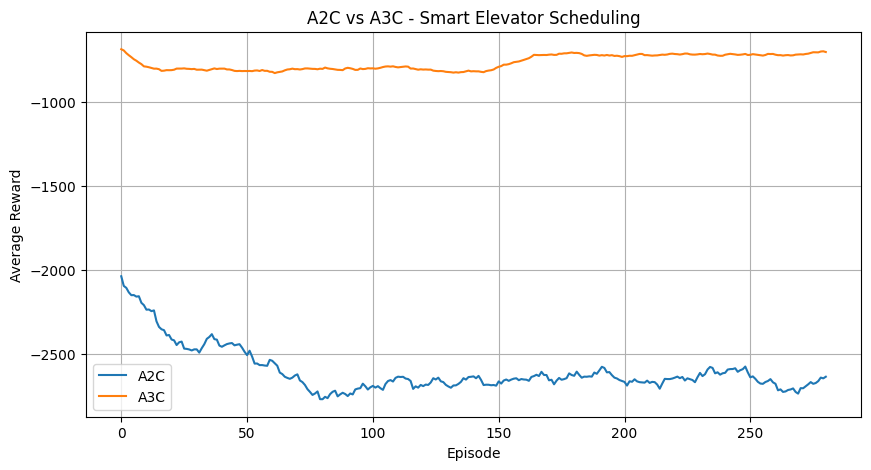


========== FINAL RESULTS ==========
A2C Average Reward: -2636.35
A3C Average Reward: -701.9

Higher reward means lower passenger waiting time.


In [5]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import multiprocessing as mp

# ============================================================
# Smart Elevator Environment
# ============================================================

class ElevatorEnv:

    def __init__(self):
        self.floors = 5
        self.max_steps = 50

    def reset(self):
        self.elevator = 0
        self.passengers = np.zeros(self.floors)
        self.steps = 0

        # Random passengers
        for i in range(self.floors):
            self.passengers[i] = np.random.randint(0, 4)

        return self.get_state()

    def get_state(self):
        return np.concatenate([
            [self.elevator],
            self.passengers
        ]).astype(np.float32)

    def step(self, action):

        # Actions:
        # 0 = Stay
        # 1 = Move Up
        # 2 = Move Down

        if action == 1 and self.elevator < self.floors - 1:
            self.elevator += 1

        elif action == 2 and self.elevator > 0:
            self.elevator -= 1

        # Passengers waiting
        waiting = np.sum(self.passengers)

        # Elevator serves passengers at current floor
        served = min(
            self.passengers[self.elevator],
            2
        )

        self.passengers[self.elevator] -= served

        # New passenger arrivals
        new_passengers = np.random.randint(
            0, 2, self.floors
        )

        self.passengers += new_passengers

        # Reward = negative waiting time
        waiting = np.sum(self.passengers)

        reward = -waiting

        self.steps += 1

        done = self.steps >= self.max_steps

        return self.get_state(), reward, done


# ============================================================
# Actor-Critic Network
# ============================================================

class ActorCritic(nn.Module):

    def __init__(self, state_size=6, action_size=3):

        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        # Actor
        self.actor = nn.Linear(
            64,
            action_size
        )

        # Critic
        self.critic = nn.Linear(
            64,
            1
        )

    def forward(self, state):

        x = self.shared(state)

        action_probs = torch.softmax(
            self.actor(x),
            dim=-1
        )

        value = self.critic(x)

        return action_probs, value


# ============================================================
# A2C Training
# ============================================================

def train_a2c(episodes=300):

    env = ElevatorEnv()

    model = ActorCritic()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    gamma = 0.99

    reward_history = []

    for episode in range(episodes):

        state = env.reset()

        log_probs = []
        values = []
        rewards = []

        for step in range(50):

            state_tensor = torch.FloatTensor(
                state
            ).unsqueeze(0)

            probs, value = model(
                state_tensor
            )

            distribution = torch.distributions.Categorical(
                probs
            )

            action = distribution.sample()

            next_state, reward, done = env.step(
                action.item()
            )

            log_probs.append(
                distribution.log_prob(action)
            )

            values.append(value.squeeze())

            rewards.append(reward)

            state = next_state

            if done:
                break

        # Calculate returns
        returns = []
        G = 0

        for reward in reversed(rewards):

            G = reward + gamma * G

            returns.insert(
                0,
                G
            )

        returns = torch.tensor(
            returns,
            dtype=torch.float32
        )

        values = torch.stack(values)

        log_probs = torch.stack(log_probs)

        # Advantage
        advantages = returns - values.detach()

        # Actor loss
        actor_loss = -(
            log_probs * advantages
        ).mean()

        # Critic loss
        critic_loss = (
            returns - values
        ).pow(2).mean()

        loss = (
            actor_loss +
            0.5 * critic_loss
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        reward_history.append(
            sum(rewards)
        )

        if episode % 50 == 0:

            print(
                "A2C Episode:",
                episode,
                "Reward:",
                round(sum(rewards), 2)
            )

    return reward_history


# ============================================================
# A3C Training
# ============================================================

def train_a3c(episodes=300):

    env = ElevatorEnv()

    model = ActorCritic()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    gamma = 0.99

    reward_history = []

    # Multiple asynchronous workers are simulated
    workers = 4

    for episode in range(episodes):

        worker_rewards = []

        for worker in range(workers):

            state = env.reset()

            log_probs = []
            values = []
            rewards = []

            for step in range(25):

                state_tensor = torch.FloatTensor(
                    state
                ).unsqueeze(0)

                probs, value = model(
                    state_tensor
                )

                distribution = torch.distributions.Categorical(
                    probs
                )

                action = distribution.sample()

                next_state, reward, done = env.step(
                    action.item()
                )

                log_probs.append(
                    distribution.log_prob(action)
                )

                values.append(
                    value.squeeze()
                )

                rewards.append(
                    reward
                )

                state = next_state

                if done:
                    break

            returns = []
            G = 0

            for reward in reversed(rewards):

                G = reward + gamma * G

                returns.insert(
                    0,
                    G
                )

            returns = torch.tensor(
                returns,
                dtype=torch.float32
            )

            values = torch.stack(values)

            log_probs = torch.stack(
                log_probs
            )

            advantages = (
                returns -
                values.detach()
            )

            actor_loss = -(
                log_probs *
                advantages
            ).mean()

            critic_loss = (
                returns -
                values
            ).pow(2).mean()

            loss = (
                actor_loss +
                0.5 * critic_loss
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            worker_rewards.append(
                sum(rewards)
            )

        reward_history.append(
            np.mean(worker_rewards)
        )

        if episode % 50 == 0:

            print(
                "A3C Episode:",
                episode,
                "Reward:",
                round(
                    np.mean(worker_rewards),
                    2
                )
            )

    return reward_history


# ============================================================
# Train A2C
# ============================================================

print("\nTraining A2C...\n")

a2c_rewards = train_a2c(300)


# ============================================================
# Train A3C
# ============================================================

print("\nTraining A3C...\n")

a3c_rewards = train_a3c(300)


# ============================================================
# Plot Comparison
# ============================================================

plt.figure(figsize=(10, 5))

a2c_avg = np.convolve(
    a2c_rewards,
    np.ones(20) / 20,
    mode="valid"
)

a3c_avg = np.convolve(
    a3c_rewards,
    np.ones(20) / 20,
    mode="valid"
)

plt.plot(
    a2c_avg,
    label="A2C"
)

plt.plot(
    a3c_avg,
    label="A3C"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "A2C vs A3C - Smart Elevator Scheduling"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# Final Performance
# ============================================================

print("\n========== FINAL RESULTS ==========")

print(
    "A2C Average Reward:",
    round(np.mean(a2c_rewards[-20:]), 2)
)

print(
    "A3C Average Reward:",
    round(np.mean(a3c_rewards[-20:]), 2)
)

print("\nHigher reward means lower passenger waiting time.")

15


========== TRAINING PPO ==========

PPO Episode: 0 Reward: 0.914
PPO Episode: 20 Reward: 0.928
PPO Episode: 40 Reward: 0.951
PPO Episode: 60 Reward: 0.937
PPO Episode: 80 Reward: 0.932

========== TRAINING TRPO ==========

TRPO Episode: 0 Reward: 0.924
TRPO Episode: 20 Reward: 0.94
TRPO Episode: 40 Reward: 0.943
TRPO Episode: 60 Reward: 0.93
TRPO Episode: 80 Reward: 0.903


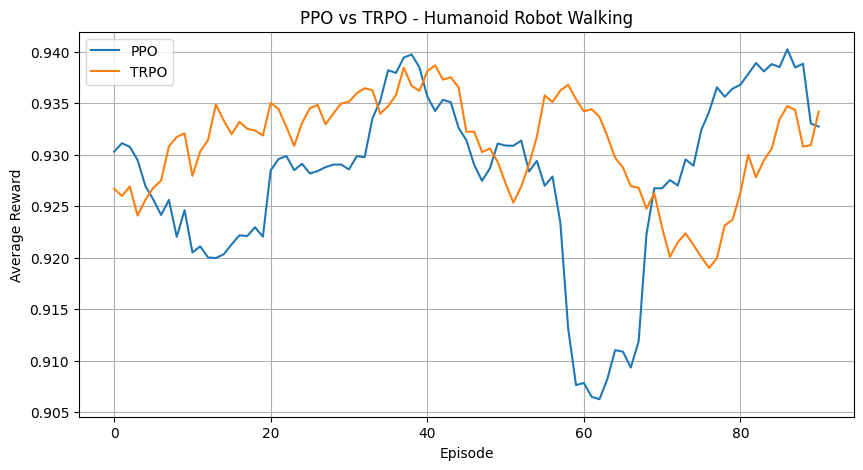


========== FINAL RESULTS ==========
PPO Average Reward: 0.933
TRPO Average Reward: 0.934

Higher reward indicates better walking stability.


In [6]:
!pip install numpy matplotlib torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# HUMANOID WALKING ENVIRONMENT
# ============================================================

class HumanoidEnv:

    def __init__(self):
        self.max_steps = 100

    def reset(self):
        self.position = 0.0
        self.velocity = 0.0
        self.balance = 0.0
        self.step_count = 0

        return self.state()

    def state(self):
        return np.array([
            self.position,
            self.velocity,
            self.balance
        ], dtype=np.float32)

    def step(self, action):

        # Actions:
        # 0 = Move Left
        # 1 = Stay
        # 2 = Move Right

        movement = [-0.1, 0.0, 0.1]

        self.velocity = movement[action]

        self.position += self.velocity

        # Balance changes slightly
        self.balance += np.random.normal(0, 0.03)

        # Control helps maintain balance
        if action == 1:
            self.balance *= 0.8

        # Reward for stable walking
        reward = (
            1.0
            - abs(self.balance)
            - 0.1 * abs(self.velocity)
        )

        # Falling condition
        done = abs(self.balance) > 1.0

        self.step_count += 1

        if self.step_count >= self.max_steps:
            done = True

        return self.state(), reward, done


# ============================================================
# ACTOR-CRITIC NETWORK
# ============================================================

class ActorCritic(nn.Module):

    def __init__(self):

        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )

        self.actor = nn.Linear(64, 3)

        self.critic = nn.Linear(64, 1)

    def forward(self, state):

        x = self.shared(state)

        logits = self.actor(x)

        value = self.critic(x)

        return logits, value


# ============================================================
# COLLECT EXPERIENCE
# ============================================================

def collect_data(env, model, steps=500):

    states = []
    actions = []
    rewards = []
    log_probs = []
    values = []
    dones = []

    state = env.reset()

    for _ in range(steps):

        state_tensor = torch.FloatTensor(
            state
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            logits, value = model(
                state_tensor
            )

            distribution = torch.distributions.Categorical(
                logits=logits
            )

            action = distribution.sample()

            log_prob = distribution.log_prob(
                action
            )

        next_state, reward, done = env.step(
            action.item()
        )

        states.append(state)
        actions.append(action.item())
        rewards.append(reward)
        log_probs.append(log_prob.item())
        values.append(value.item())
        dones.append(done)

        state = next_state

        if done:
            state = env.reset()

    return (
        np.array(states),
        np.array(actions),
        np.array(rewards),
        np.array(log_probs),
        np.array(values),
        np.array(dones)
    )


# ============================================================
# CALCULATE RETURNS
# ============================================================

def calculate_returns(rewards, gamma=0.99):

    returns = []
    G = 0

    for reward in reversed(rewards):

        G = reward + gamma * G

        returns.insert(0, G)

    return np.array(returns)


# ============================================================
# PPO
# ============================================================

def train_ppo(episodes=100):

    env = HumanoidEnv()

    model = ActorCritic().to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0003
    )

    history = []

    for episode in range(episodes):

        (
            states,
            actions,
            rewards,
            old_log_probs,
            values,
            dones
        ) = collect_data(
            env,
            model,
            200
        )

        returns = calculate_returns(
            rewards
        )

        states_t = torch.FloatTensor(
            states
        ).to(device)

        actions_t = torch.LongTensor(
            actions
        ).to(device)

        old_log_probs_t = torch.FloatTensor(
            old_log_probs
        ).to(device)

        returns_t = torch.FloatTensor(
            returns
        ).to(device)

        for _ in range(4):

            logits, new_values = model(
                states_t
            )

            distribution = torch.distributions.Categorical(
                logits=logits
            )

            new_log_probs = distribution.log_prob(
                actions_t
            )

            ratio = torch.exp(
                new_log_probs -
                old_log_probs_t
            )

            advantages = (
                returns_t -
                new_values.squeeze()
            )

            advantages = (
                advantages -
                advantages.mean()
            ) / (
                advantages.std() + 1e-8
            )

            epsilon = 0.2

            clipped_ratio = torch.clamp(
                ratio,
                1 - epsilon,
                1 + epsilon
            )

            actor_loss = -torch.min(
                ratio * advantages,
                clipped_ratio * advantages
            ).mean()

            critic_loss = (
                returns_t -
                new_values.squeeze()
            ).pow(2).mean()

            loss = (
                actor_loss +
                0.5 * critic_loss
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        history.append(
            np.mean(rewards)
        )

        if episode % 20 == 0:
            print(
                "PPO Episode:",
                episode,
                "Reward:",
                round(np.mean(rewards), 3)
            )

    return model, history


# ============================================================
# TRPO
# ============================================================

def train_trpo(episodes=100):

    env = HumanoidEnv()

    model = ActorCritic().to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    history = []

    for episode in range(episodes):

        (
            states,
            actions,
            rewards,
            old_log_probs,
            values,
            dones
        ) = collect_data(
            env,
            model,
            200
        )

        returns = calculate_returns(
            rewards
        )

        states_t = torch.FloatTensor(
            states
        ).to(device)

        actions_t = torch.LongTensor(
            actions
        ).to(device)

        returns_t = torch.FloatTensor(
            returns
        ).to(device)

        old_log_probs_t = torch.FloatTensor(
            old_log_probs
        ).to(device)

        logits, values_new = model(
            states_t
        )

        distribution = torch.distributions.Categorical(
            logits=logits
        )

        new_log_probs = distribution.log_prob(
            actions_t
        )

        advantages = (
            returns_t -
            values_new.squeeze()
        )

        advantages = (
            advantages -
            advantages.mean()
        ) / (
            advantages.std() + 1e-8
        )

        # Policy ratio
        ratio = torch.exp(
            new_log_probs -
            old_log_probs_t
        )

        # Conservative update
        surrogate = (
            ratio * advantages
        ).mean()

        value_loss = (
            returns_t -
            values_new.squeeze()
        ).pow(2).mean()

        loss = -surrogate + 0.5 * value_loss

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            0.5
        )

        optimizer.step()

        history.append(
            np.mean(rewards)
        )

        if episode % 20 == 0:
            print(
                "TRPO Episode:",
                episode,
                "Reward:",
                round(np.mean(rewards), 3)
            )

    return model, history


# ============================================================
# TRAIN PPO
# ============================================================

print("\n========== TRAINING PPO ==========\n")

ppo_model, ppo_rewards = train_ppo(
    episodes=100
)


# ============================================================
# TRAIN TRPO
# ============================================================

print("\n========== TRAINING TRPO ==========\n")

trpo_model, trpo_rewards = train_trpo(
    episodes=100
)


# ============================================================
# PERFORMANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

ppo_avg = np.convolve(
    ppo_rewards,
    np.ones(10) / 10,
    mode="valid"
)

trpo_avg = np.convolve(
    trpo_rewards,
    np.ones(10) / 10,
    mode="valid"
)

plt.plot(
    ppo_avg,
    label="PPO"
)

plt.plot(
    trpo_avg,
    label="TRPO"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "PPO vs TRPO - Humanoid Robot Walking"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n========== FINAL RESULTS ==========")

print(
    "PPO Average Reward:",
    round(np.mean(ppo_rewards[-10:]), 3)
)

print(
    "TRPO Average Reward:",
    round(np.mean(trpo_rewards[-10:]), 3)
)

print("\nHigher reward indicates better walking stability.")